In [70]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import torch.nn as nn
import sklearn.preprocessing
import torch.optim as optim
import talib as ta

**Extract Stock Data From Yfinance (Take Dummy Stock)**

In [71]:
user_in = input("What ticker would you like to use? (type 'd' for default)")
ticker = user_in if user_in != 'd' else 'AAPL'
data_df = yf.download(ticker, start="2022-1-1", end="2026-01-02")

[*********************100%***********************]  1 of 1 completed


In [72]:
data_df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103638,178.954976,173.895938,174.013357,104487900
2022-01-04,175.843246,179.013714,175.275693,178.710370,99310400
2022-01-05,171.165848,176.303172,170.891858,175.755193,94537600
2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000
2022-01-07,168.474838,170.402559,167.359306,169.179387,86709100
...,...,...,...,...,...
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800


**We will compare how engineered features including SMA, EMA, etc correlate**|

In [73]:
cols = ['SMA_20', 'EMA_10', 'RSI_14', 'ROC_10', 'VOL_20', 'VOLUME_20_D', 'SKEW_20', 'KURT_20']
df = pd.DataFrame(columns=cols)
data_df.columns = data_df.columns.droplevel(1)

In [74]:
data_df['Close']

Date
2022-01-03    178.103638
2022-01-04    175.843246
2022-01-05    171.165848
2022-01-06    168.308517
2022-01-07    168.474838
                 ...    
2025-12-24    273.554016
2025-12-26    273.144409
2025-12-29    273.504089
2025-12-30    272.824707
2025-12-31    271.605835
Name: Close, Length: 1003, dtype: float64

In [75]:
prices = data_df['Close'].values
df['SMA_20'] = ta.SMA(prices, timeperiod=20)
df['EMA_10'] = ta.EMA(prices, timeperiod=10)
df['RSI_14'] = ta.RSI(prices, timeperiod=14)
df['ROC_10'] = ta.ROC(prices, timeperiod=10)
df['VOL_20'] = ta.STDDEV(prices, timeperiod=20)
df['VOLUME_20_D'] = ta.SMA(data_df['Volume'].values.astype(float), timeperiod=20)
df['VOLUME_20_D'] = data_df['Volume'].values.astype(float) - df['VOLUME_20_D']
df['SKEW_20'] = data_df['Close'].rolling(window=20).skew().values.astype(float)
df['KURT_20'] = data_df['Close'].rolling(window=20).kurt().values.astype(float)

In [76]:
df

,SMA_20,EMA_10,RSI_14,ROC_10,VOL_20,VOLUME_20_D,SKEW_20,KURT_20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
998,276.892905,273.700999,50.012072,-1.782771,4.134875,-26260680.0,0.465693,-0.362790
999,276.685599,273.599801,49.168915,-1.665288,4.212940,-22054000.0,0.562093,-0.436652
1000,276.431337,273.582399,49.966593,-1.624264,4.243714,-20039580.0,0.717140,-0.328885
1001,275.930804,273.444637,48.420933,-0.375756,4.044551,-20392775.0,0.979162,0.446620


<function matplotlib.pyplot.show(close=None, block=None)>

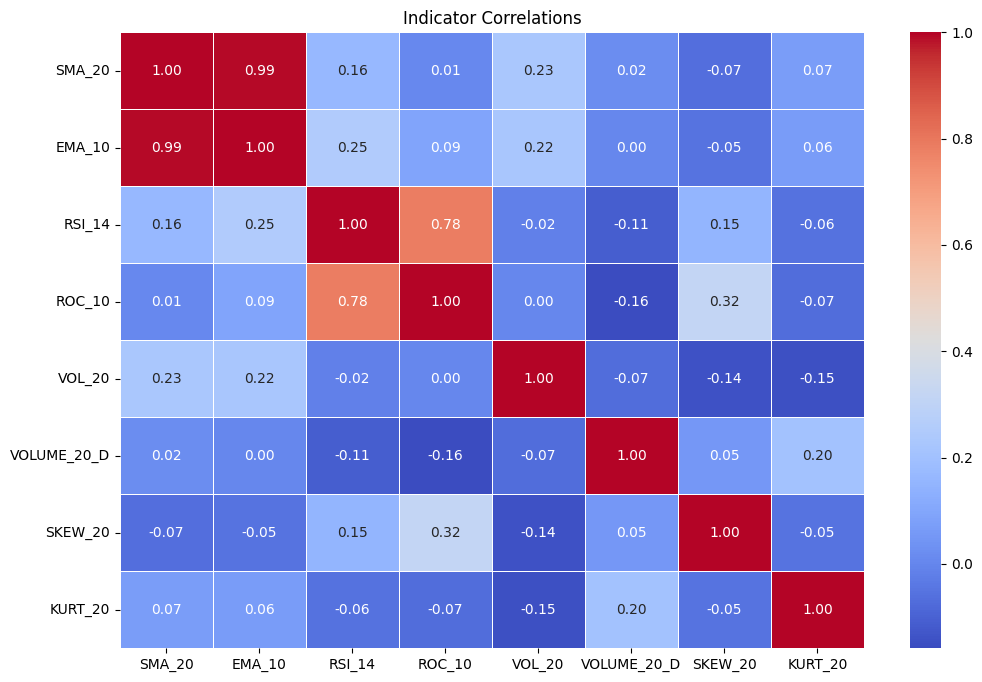

In [77]:
corr_mat = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt= '.2f', linewidths=0.5)
plt.title('Indicator Correlations')
plt.show

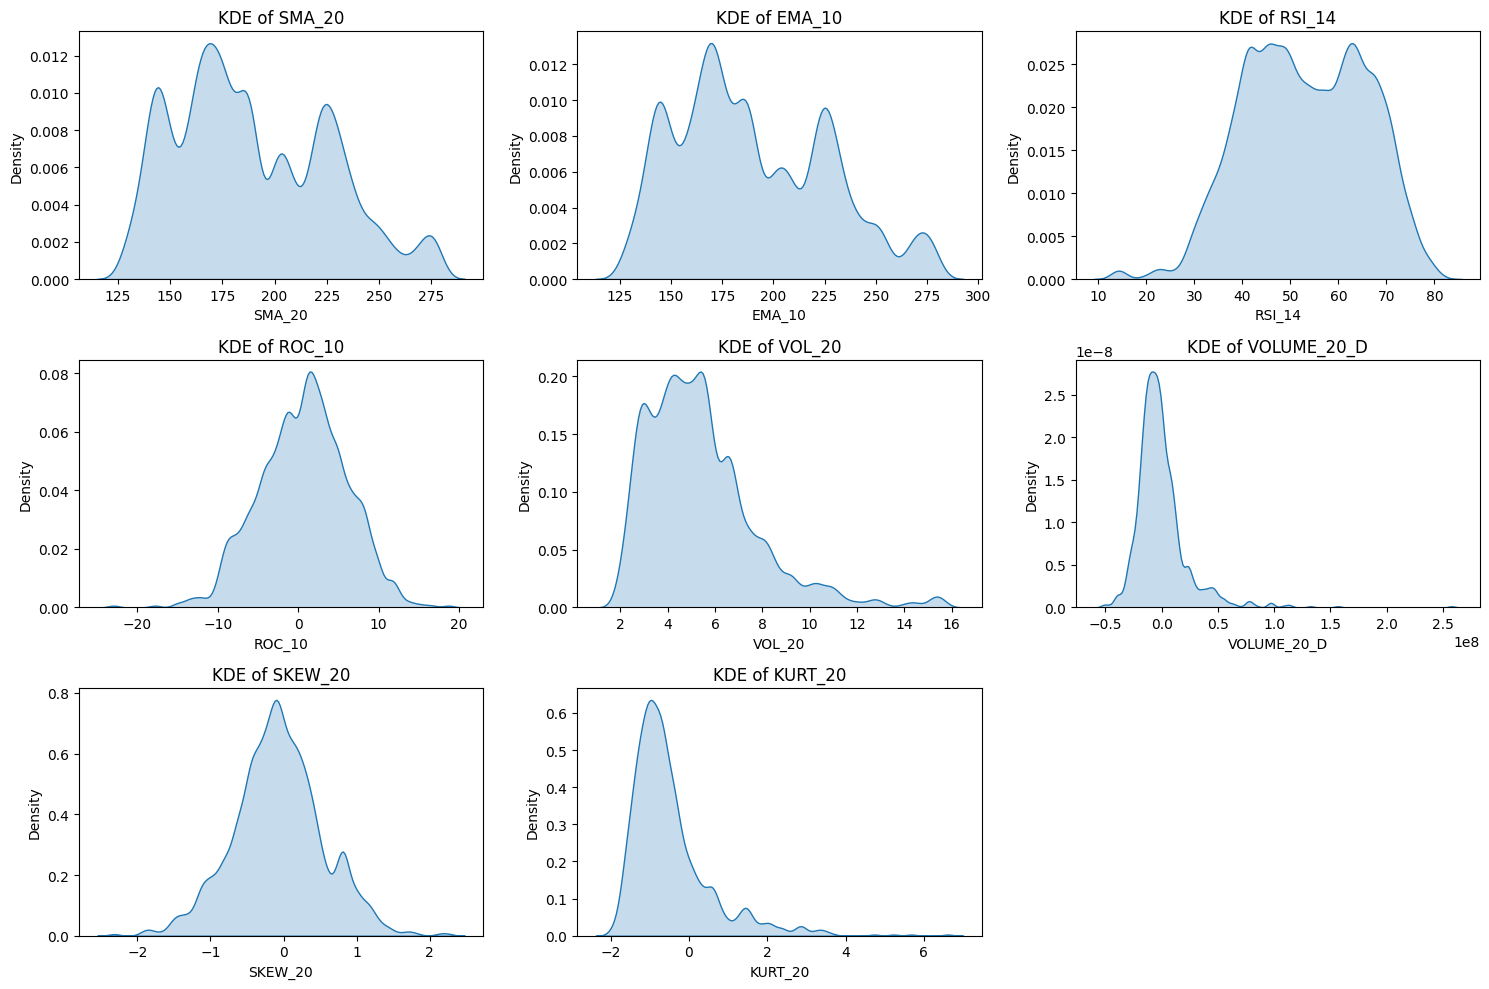

In [78]:
plot_cols = df.columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(df[col].dropna(), fill=True, bw_adjust=0.5)
    plt.title(f'KDE of {col}')

plt.tight_layout()
plt.show()